# TCC — Piloto de dados v2: ERA5 + DETER/TerraBrasilis

Esta versão corrige dois comportamentos observados no piloto inicial:

1. **ERA5 / CDS:** variáveis com `stepType` diferentes podem ser separadas em arquivos distintos (`instant` e `accum`).
2. **TerraBrasilis / WFS:** o nome da camada não é mais assumido como `deter_public`; o caderno consulta `GetCapabilities` e `DescribeFeatureType`.

O objetivo é validar aquisição, abertura, inspeção e pré-processamento antes de escalar para séries longas.

## 0. Ambiente

```bash
python -m venv .venv
# Linux/macOS
source .venv/bin/activate
# Windows PowerShell:
# .venv\Scripts\Activate.ps1

python -m pip install --upgrade pip
pip install -r requirements-tcc-v2.txt
jupyter lab
```

Para o ERA5, configure `~/.cdsapirc` e aceite os termos do dataset no CDS.

**Nunca versione `.cdsapirc` ou tokens no GitHub.**

In [1]:
from pathlib import Path
import sys
import platform
import shutil
import zipfile

ROOT = Path.cwd()
DATA_RAW = ROOT / "data" / "raw"
DATA_INTERIM = ROOT / "data" / "interim"
DATA_PROCESSED = ROOT / "data" / "processed"

for p in (DATA_RAW, DATA_INTERIM, DATA_PROCESSED):
    p.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version.split()[0])
print("Sistema:", platform.platform())
print("Diretório:", ROOT.resolve())

Python: 3.11.7
Sistema: Linux-7.0.0-28-generic-x86_64-with-glibc2.39
Diretório: /home/thalles24006/TCC


In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("xarray:", xr.__version__)

numpy: 2.4.6
pandas: 3.0.5
xarray: 2026.7.0


# Parte A — ERA5

## 1. Configuração do piloto

A caixa espacial é apenas para teste. Para precipitação diária solicitamos um dia adicional, porque a amostra acumulada em `00:00` representa a hora que termina em `00:00`, portanto pertence parcialmente ao dia anterior.

In [3]:
AREA = [-1.0, -56.0, -4.0, -53.5]  # [N, W, S, E]

ANO = "2024"
MES = "08"

SCIENCE_START = "2024-08-01"
SCIENCE_END = "2024-08-07"

# Um dia extra para fechar corretamente o último dia de precipitação.
DIAS_DOWNLOAD = [f"{d:02d}" for d in range(1, 9)]
HORAS = [f"{h:02d}:00" for h in range(24)]

VARIAVEIS_INSTANT = [
    "2m_temperature",
    "2m_dewpoint_temperature",
    "surface_pressure",
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
]

VARIAVEIS_ACCUM = [
    "total_precipitation",
]

ERA5_DIR = DATA_RAW / "era5_piloto_2024-08"
ERA5_DIR.mkdir(parents=True, exist_ok=True)
ERA5_DIR

PosixPath('/home/thalles24006/TCC/data/raw/era5_piloto_2024-08')

## 2. Download robusto do CDS

Fazemos duas solicitações independentes: uma para variáveis instantâneas e outra para acumuladas.

A função abaixo também testa o payload com `zipfile.is_zipfile()`; assim, se o CDS voltar a empacotar múltiplos NetCDFs, o notebook extrai automaticamente.

In [4]:
import cdsapi

cdsapirc = Path.home() / ".cdsapirc"
if not cdsapirc.exists():
    print("ATENÇÃO: ~/.cdsapirc não encontrado. Configure o CDS antes do download.")
else:
    print("OK: ~/.cdsapirc encontrado.")

OK: ~/.cdsapirc encontrado.


In [5]:
def retrieve_cds_netcdf(client, dataset, request, output_dir, stem):
    # Baixa uma solicitação CDS sem assumir que o payload será NetCDF puro.
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    existing = sorted(output_dir.glob(f"{stem}*.nc"))
    if existing:
        print(f"[cache] {stem}: {len(existing)} NetCDF(s) encontrado(s).")
        return existing

    payload = output_dir / f"{stem}.download"

    if not payload.exists():
        print(f"[CDS] baixando {stem}...")
        client.retrieve(dataset, request).download(str(payload))
    else:
        print(f"[cache] payload existente: {payload}")

    if zipfile.is_zipfile(payload):
        extract_dir = output_dir / f"{stem}_extracted"
        extract_dir.mkdir(exist_ok=True)

        with zipfile.ZipFile(payload) as zf:
            zf.extractall(extract_dir)

        nc_files = sorted(extract_dir.rglob("*.nc"))
        if not nc_files:
            raise RuntimeError(
                f"O payload {payload} é ZIP, mas nenhum .nc foi encontrado."
            )

        print(f"[ZIP] extraídos {len(nc_files)} NetCDF(s):")
        for p in nc_files:
            print("  -", p.name)
        return nc_files

    target = output_dir / f"{stem}.nc"
    shutil.move(str(payload), str(target))
    print("[NetCDF]", target.name)
    return [target]

In [6]:
dataset = "reanalysis-era5-single-levels"

request_base = {
    "product_type": ["reanalysis"],
    "year": [ANO],
    "month": [MES],
    "day": DIAS_DOWNLOAD,
    "time": HORAS,
    "data_format": "netcdf",
    "download_format": "unarchived",
    "area": AREA,
}

request_instant = {
    **request_base,
    "variable": VARIAVEIS_INSTANT,
}

request_accum = {
    **request_base,
    "variable": VARIAVEIS_ACCUM,
}

client = cdsapi.Client()

instant_files = retrieve_cds_netcdf(
    client, dataset, request_instant, ERA5_DIR, "era5_instant"
)

accum_files = retrieve_cds_netcdf(
    client, dataset, request_accum, ERA5_DIR, "era5_accum"
)

print("Instant:", instant_files)
print("Accum:", accum_files)

[CDS] baixando era5_instant...


2026-08-10 19:47:33,306 INFO Request ID is 7c773d21-f8cd-44db-b379-a5a32a72f456
2026-08-10 19:47:33,482 INFO status has been updated to accepted
2026-08-10 19:53:55,028 INFO status has been updated to successful


[NetCDF] era5_instant.nc
[CDS] baixando era5_accum...


2026-08-10 19:53:58,218 INFO Request ID is ab315393-a72e-4bce-852e-68805ac02e75
2026-08-10 19:53:58,393 INFO status has been updated to accepted
2026-08-10 19:54:12,442 INFO status has been updated to running
2026-08-10 19:54:31,782 INFO status has been updated to successful
                                                                                         

[NetCDF] era5_accum.nc
Instant: [PosixPath('/home/thalles24006/TCC/data/raw/era5_piloto_2024-08/era5_instant.nc')]
Accum: [PosixPath('/home/thalles24006/TCC/data/raw/era5_piloto_2024-08/era5_accum.nc')]


### Caso você já tenha o ZIP antigo

A função abaixo inspeciona e extrai o arquivo já baixado.

In [7]:
def inspect_and_extract_existing_era5_zip(zip_path, destination=None):
    zip_path = Path(zip_path)

    if not zipfile.is_zipfile(zip_path):
        raise ValueError(f"{zip_path} não é reconhecido como ZIP.")

    destination = Path(destination or zip_path.with_suffix(""))
    destination.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path) as zf:
        print("Conteúdo:")
        for name in zf.namelist():
            print("  -", name)
        zf.extractall(destination)

    files = sorted(destination.rglob("*.nc"))
    print(f"NetCDF(s) extraído(s): {len(files)}")
    return files

# Exemplo:
# arquivos_antigos = inspect_and_extract_existing_era5_zip(
#     DATA_RAW / "meu_download_era5.zip"
# )

## 3. Abrir e combinar `instant` e `accum`

O merge só acontece depois da verificação de alinhamento exato das coordenadas principais.

In [8]:
def drop_aux_forecast_coords(ds):
    candidates = ["step", "forecast_reference_time"]
    drop = [
        name for name in candidates
        if name in ds.coords and name not in ds.dims
    ]
    if drop:
        ds = ds.drop_vars(drop)
    return ds


def open_netcdf_group(paths):
    datasets = []
    for p in paths:
        d = xr.open_dataset(p)
        d = drop_aux_forecast_coords(d)
        datasets.append(d)

    if len(datasets) == 1:
        return datasets[0]

    return xr.merge(datasets, compat="no_conflicts", join="exact")


ds_instant = open_netcdf_group(instant_files)
ds_accum = open_netcdf_group(accum_files)

print("INSTANT")
print(ds_instant)
print("\nACCUM")
print(ds_accum)

INSTANT
<xarray.Dataset> Size: 554kB
Dimensions:     (valid_time: 192, latitude: 13, longitude: 11)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2kB 2024-08-01 ... 2024-08-08T23:...
    expver      (valid_time) <U4 3kB ...
  * latitude    (latitude) float64 104B -1.0 -1.25 -1.5 ... -3.5 -3.75 -4.0
  * longitude   (longitude) float64 88B -56.0 -55.75 -55.5 ... -53.75 -53.5
    number      int64 8B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 110kB ...
    d2m         (valid_time, latitude, longitude) float32 110kB ...
    sp          (valid_time, latitude, longitude) float32 110kB ...
    u10         (valid_time, latitude, longitude) float32 110kB ...
    v10         (valid_time, latitude, longitude) float32 110kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             Europe

In [9]:
ds_instant_aligned, ds_accum_aligned = xr.align(
    ds_instant,
    ds_accum,
    join="exact",
)

ds = xr.merge(
    [ds_instant_aligned, ds_accum_aligned],
    compat="no_conflicts",
    join="exact",
)

ds

<xarray.Dataset> Size: 664kB
Dimensions:     (valid_time: 192, latitude: 13, longitude: 11)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2kB 2024-08-01 ... 2024-08-08T23:...
    expver      (valid_time) <U4 3kB '0001' '0001' '0001' ... '0001' '0001'
  * latitude    (latitude) float64 104B -1.0 -1.25 -1.5 ... -3.5 -3.75 -4.0
  * longitude   (longitude) float64 88B -56.0 -55.75 -55.5 ... -53.75 -53.5
    number      int64 8B 0
Data variables:
    t2m         (valid_time, latitude, longitude) float32 110kB ...
    d2m         (valid_time, latitude, longitude) float32 110kB ...
    sp          (valid_time, latitude, longitude) float32 110kB ...
    u10         (valid_time, latitude, longitude) float32 110kB ...
    v10         (valid_time, latitude, longitude) float32 110kB ...
    tp          (valid_time, latitude, longitude) float32 110kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-08-10T22:53 GRIB to CDM+CF via cfgrib-0.9.1...

In [10]:
print("Dimensões:", dict(ds.sizes))
print("Variáveis:", list(ds.data_vars))
print("Coordenadas:", list(ds.coords))

time_name = "valid_time" if "valid_time" in ds.coords else "time"
lat_name = "latitude" if "latitude" in ds.coords else "lat"
lon_name = "longitude" if "longitude" in ds.coords else "lon"

print("Tempo:", time_name)
print("Latitude:", lat_name)
print("Longitude:", lon_name)

Dimensões: {'valid_time': 192, 'latitude': 13, 'longitude': 11}
Variáveis: ['t2m', 'd2m', 'sp', 'u10', 'v10', 'tp']
Coordenadas: ['number', 'valid_time', 'latitude', 'longitude', 'expver']
Tempo: valid_time
Latitude: latitude
Longitude: longitude


## 4. Variáveis derivadas

`tp` é convertido para milímetros, mas mantemos no nome a interpretação correta: precipitação acumulada **na hora que termina em `valid_time`**.

In [11]:
def sat_vapor_pressure_kpa(temp_c):
    return 0.6108 * np.exp((17.27 * temp_c) / (temp_c + 237.3))

derived = xr.Dataset(coords=ds.coords)

if "t2m" in ds:
    derived["t2m_c"] = ds["t2m"] - 273.15
    derived["t2m_c"].attrs.update(units="degC")

if "d2m" in ds:
    derived["d2m_c"] = ds["d2m"] - 273.15
    derived["d2m_c"].attrs.update(units="degC")

if "t2m_c" in derived and "d2m_c" in derived:
    es = sat_vapor_pressure_kpa(derived["t2m_c"])
    ea = sat_vapor_pressure_kpa(derived["d2m_c"])
    derived["vpd_kpa"] = xr.where(es - ea < 0, 0, es - ea)
    derived["vpd_kpa"].attrs.update(units="kPa")

if "sp" in ds:
    derived["surface_pressure_hpa"] = ds["sp"] / 100.0
    derived["surface_pressure_hpa"].attrs.update(units="hPa")

if "tp" in ds:
    derived["precip_mm_hour_ending"] = ds["tp"] * 1000.0
    derived["precip_mm_hour_ending"].attrs.update(
        units="mm",
        long_name="hourly precipitation accumulation ending at valid_time",
    )

if "u10" in ds and "v10" in ds:
    derived["wind_speed_10m"] = np.hypot(ds["u10"], ds["v10"])
    derived["wind_speed_10m"].attrs.update(units="m s-1")

derived

<xarray.Dataset> Size: 664kB
Dimensions:                (valid_time: 192, latitude: 13, longitude: 11)
Coordinates:
  * valid_time             (valid_time) datetime64[ns] 2kB 2024-08-01 ... 202...
    expver                 (valid_time) <U4 3kB '0001' '0001' ... '0001' '0001'
  * latitude               (latitude) float64 104B -1.0 -1.25 ... -3.75 -4.0
  * longitude              (longitude) float64 88B -56.0 -55.75 ... -53.75 -53.5
    number                 int64 8B 0
Data variables:
    t2m_c                  (valid_time, latitude, longitude) float32 110kB 26...
    d2m_c                  (valid_time, latitude, longitude) float32 110kB 21...
    vpd_kpa                (valid_time, latitude, longitude) float32 110kB 1....
    surface_pressure_hpa   (valid_time, latitude, longitude) float32 110kB 99...
    precip_mm_hour_ending  (valid_time, latitude, longitude) float32 110kB 0....
    wind_speed_10m         (valid_time, latitude, longitude) float32 110kB 1....

## 5. Série em um ponto de grade

In [12]:
lat0 = (AREA[0] + AREA[2]) / 2
lon0 = (AREA[1] + AREA[3]) / 2

point = derived.sel(
    {lat_name: lat0, lon_name: lon0},
    method="nearest"
).sortby(time_name)

print("Ponto solicitado:", lat0, lon0)
print("Ponto usado:", float(point[lat_name]), float(point[lon_name]))
point

Ponto solicitado: -2.5 -54.75
Ponto usado: -2.5 -54.75


<xarray.Dataset> Size: 9kB
Dimensions:                (valid_time: 192)
Coordinates:
  * valid_time             (valid_time) datetime64[ns] 2kB 2024-08-01 ... 202...
    expver                 (valid_time) <U4 3kB '0001' '0001' ... '0001' '0001'
    number                 int64 8B 0
    latitude               float64 8B -2.5
    longitude              float64 8B -54.75
Data variables:
    t2m_c                  (valid_time) float32 768B 29.19 28.85 ... 31.12 30.53
    d2m_c                  (valid_time) float32 768B 24.32 24.3 ... 22.46 23.23
    vpd_kpa                (valid_time) float32 768B 1.007 0.9339 ... 1.525
    surface_pressure_hpa   (valid_time) float32 768B 1.007e+03 ... 1.003e+03
    precip_mm_hour_ending  (valid_time) float32 768B 0.0 0.0 0.0 ... 0.0 0.0
    wind_speed_10m         (valid_time) float32 768B 2.658 3.166 ... 3.091 3.353

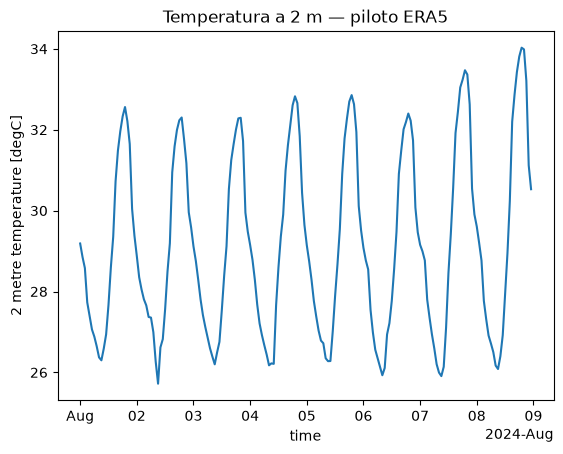

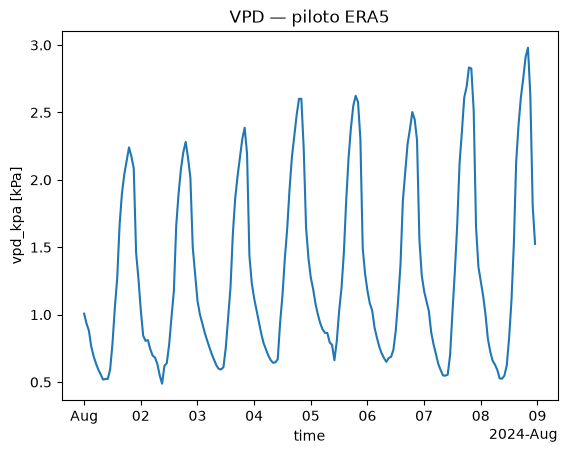

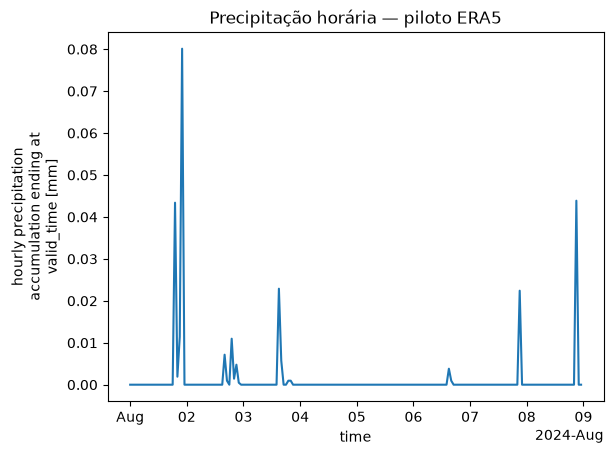

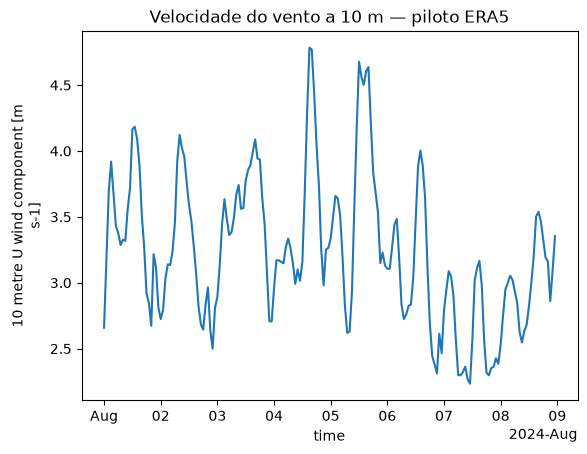

In [13]:
for var, title in [
    ("t2m_c", "Temperatura a 2 m"),
    ("vpd_kpa", "VPD"),
    ("precip_mm_hour_ending", "Precipitação horária"),
    ("wind_speed_10m", "Velocidade do vento a 10 m"),
]:
    if var in point:
        point[var].plot()
        plt.title(f"{title} — piloto ERA5")
        plt.show()

## 6. Controle de qualidade mínimo

In [14]:
df_point = point.to_dataframe().reset_index()

summary = []
for col in point.data_vars:
    s = df_point[col]
    summary.append({
        "variavel": col,
        "n": int(s.notna().sum()),
        "n_nan": int(s.isna().sum()),
        "min": float(s.min()) if s.notna().any() else np.nan,
        "media": float(s.mean()) if s.notna().any() else np.nan,
        "max": float(s.max()) if s.notna().any() else np.nan,
        "desvio": float(s.std()) if s.notna().any() else np.nan,
        "n_unicos": int(s.nunique(dropna=True)),
    })

pd.DataFrame(summary)

,variavel,n,n_nan,min,media,max,desvio,n_unicos
0,t2m_c,192,0,25.720734,29.140100,34.027985,2.304696,192
1,d2m_c,192,0,19.791779,22.592194,24.320099,1.084287,191
2,vpd_kpa,192,0,0.488012,1.323595,2.980152,0.694490,192
3,surface_pressure_hpa,192,0,1001.174988,1005.040100,1008.448120,1.632220,191
4,precip_mm_hour_ending,192,0,0.000000,0.001376,0.080109,0.007681,16
5,wind_speed_10m,192,0,2.233712,3.238930,4.783967,0.560238,192


In [15]:
time_index = pd.DatetimeIndex(df_point[time_name])
diffs = time_index.to_series().diff().dropna()

print("Passos temporais mais frequentes:")
print(diffs.value_counts().head())

expected = pd.Timedelta(hours=1)
gaps = diffs[diffs != expected]
print("Número de passos diferentes de 1 h:", len(gaps))

Passos temporais mais frequentes:
valid_time
0 days 01:00:00    191
Name: count, dtype: int64
Número de passos diferentes de 1 h: 0


## 7. Agregação diária — precipitação tratada separadamente

Para somar precipitação por dia civil UTC, deslocamos **somente a coordenada temporal da precipitação em -1 hora** antes do `resample`.

As variáveis instantâneas não são deslocadas.

In [16]:
daily = xr.Dataset()

for var in ["t2m_c", "d2m_c", "vpd_kpa", "surface_pressure_hpa", "wind_speed_10m"]:
    if var in point:
        daily[var] = point[var].resample({time_name: "1D"}).mean()

if "precip_mm_hour_ending" in point:
    precip_for_daily = point["precip_mm_hour_ending"].copy()
    precip_for_daily = precip_for_daily.assign_coords(
        {time_name: precip_for_daily[time_name] - np.timedelta64(1, "h")}
    )
    daily["precip_mm_day"] = precip_for_daily.resample({time_name: "1D"}).sum()
    daily["precip_mm_day"].attrs.update(units="mm/day")

daily = daily.sel({time_name: slice(SCIENCE_START, SCIENCE_END)})
daily

<xarray.Dataset> Size: 248B
Dimensions:               (valid_time: 7)
Coordinates:
  * valid_time            (valid_time) datetime64[ns] 56B 2024-08-01 ... 2024...
    number                int64 8B 0
    latitude              float64 8B -2.5
    longitude             float64 8B -54.75
Data variables:
    t2m_c                 (valid_time) float32 28B 29.02 28.95 ... 28.94 29.41
    d2m_c                 (valid_time) float32 28B 23.26 23.08 ... 22.24 22.42
    vpd_kpa               (valid_time) float32 28B 1.179 1.191 ... 1.331 1.424
    surface_pressure_hpa  (valid_time) float32 28B 1.006e+03 ... 1.004e+03
    wind_speed_10m        (valid_time) float32 28B 3.409 3.192 ... 3.063 2.611
    precip_mm_day         (valid_time) float32 28B 0.1369 0.02575 ... 0.02241

In [17]:
processed_nc = DATA_PROCESSED / "era5_piloto_point_daily_v2.nc"
daily.to_netcdf(processed_nc)
print("Salvo:", processed_nc)

Salvo: /home/thalles24006/TCC/data/processed/era5_piloto_point_daily_v2.nc


# Parte B — DETER / TerraBrasilis

## 8. Descobrir a camada publicada pelo WFS

Fluxo:

1. `GetCapabilities`;
2. listar `FeatureType`;
3. escolher a camada DETER Amazônia;
4. `DescribeFeatureType`;
5. identificar o campo de data;
6. `GetFeature`.

Assim o notebook não depende de `deter_public`.

In [18]:
import requests
import xml.etree.ElementTree as ET

WFS_URL = "https://terrabrasilis.dpi.inpe.br/geoserver/deter-amz/wfs"

def local_name(tag):
    return tag.split("}")[-1] if "}" in tag else tag


def get_xml(url, params, timeout=90):
    r = requests.get(url, params=params, timeout=timeout)
    r.raise_for_status()

    root = ET.fromstring(r.content)

    if local_name(root.tag) == "ExceptionReport":
        messages = [
            (el.text or "").strip()
            for el in root.iter()
            if local_name(el.tag) == "ExceptionText"
        ]
        raise RuntimeError("WFS Exception: " + " | ".join(messages))

    return root, r


def discover_feature_types(wfs_url=WFS_URL):
    root, _ = get_xml(
        wfs_url,
        {
            "service": "WFS",
            "version": "2.0.0",
            "request": "GetCapabilities",
        },
    )

    rows = []
    for ft in root.iter():
        if local_name(ft.tag) != "FeatureType":
            continue

        name = None
        title = None
        for child in ft:
            ln = local_name(child.tag)
            if ln == "Name":
                name = (child.text or "").strip()
            elif ln == "Title":
                title = (child.text or "").strip()

        if name:
            rows.append({"name": name, "title": title})

    return pd.DataFrame(rows).drop_duplicates().reset_index(drop=True)


feature_types = discover_feature_types()
print(f"Camadas publicadas no workspace: {len(feature_types)}")
feature_types

Camadas publicadas no workspace: 3


,name,title
0,deter-amz:deter_amz,DETER Daily - Anonymous
1,deter-amz:prodes_reference,prodes_reference
2,deter-amz:updated_date,updated_date


## 9. Seleção defensiva da camada

A seleção prioriza o nome local `deter_amz`. Se houver ambiguidade, o código para para evitar baixar a camada errada.

In [19]:
DETER_LAYER_OVERRIDE = None
# Se necessário:
# DETER_LAYER_OVERRIDE = "workspace:nome_exato_da_camada"

def choose_deter_layer(feature_types, override=None):
    names = feature_types["name"].tolist()

    if override:
        if override not in names:
            raise ValueError(
                f"Override {override!r} não aparece no GetCapabilities. "
                f"Camadas disponíveis: {names}"
            )
        return override

    exact = [
        n for n in names
        if n.split(":")[-1].lower() == "deter_amz"
    ]
    if len(exact) == 1:
        return exact[0]

    candidates = [
        n for n in names
        if "deter" in n.lower()
        and ("amz" in n.lower() or "amazon" in n.lower())
    ]

    if len(candidates) == 1:
        return candidates[0]

    raise RuntimeError(
        "Não foi possível escolher a camada DETER Amazônia sem ambiguidade. "
        "Defina DETER_LAYER_OVERRIDE com um nome do GetCapabilities. "
        f"Candidatas: {candidates}"
    )

DETER_LAYER = choose_deter_layer(feature_types, DETER_LAYER_OVERRIDE)
print("Camada selecionada:", DETER_LAYER)

Camada selecionada: deter-amz:deter_amz


## 10. Descobrir atributos com `DescribeFeatureType`

In [20]:
def describe_feature_fields(wfs_url, layer):
    root, _ = get_xml(
        wfs_url,
        {
            "service": "WFS",
            "version": "2.0.0",
            "request": "DescribeFeatureType",
            "typeNames": layer,
        },
    )

    fields = []
    for el in root.iter():
        if local_name(el.tag) == "element":
            name = el.attrib.get("name")
            field_type = el.attrib.get("type")
            if name:
                fields.append({"name": name, "type": field_type})

    return pd.DataFrame(fields).drop_duplicates().reset_index(drop=True)

deter_fields = describe_feature_fields(WFS_URL, DETER_LAYER)
deter_fields

,name,type
0,gid,xsd:string
1,classname,xsd:string
2,quadrant,xsd:string
3,path_row,xsd:string
4,view_date,xsd:date
5,sensor,xsd:string
6,satellite,xsd:string
7,areauckm,xsd:double
8,uc,xsd:string
9,areamunkm,xsd:double


In [21]:
def choose_date_field(fields):
    names = fields["name"].tolist()
    lower = {n.lower(): n for n in names}

    for preferred in ["date", "view_date", "image_date", "detection_date"]:
        if preferred in lower:
            return lower[preferred]

    candidates = [n for n in names if "date" in n.lower()]
    if len(candidates) == 1:
        return candidates[0]

    raise RuntimeError(
        "Campo de data não identificado com segurança. "
        f"Candidatos: {candidates}"
    )

DATE_FIELD = choose_date_field(deter_fields)
print("Campo de data:", DATE_FIELD)

Campo de data: view_date


## 11. Contar antes de baixar

Fazemos `resultType=hits` para evitar uma consulta grande inesperada.

In [22]:
DETER_START = "2024-08-01"
DETER_END = "2024-08-07"
CQL = f"{DATE_FIELD} BETWEEN '{DETER_START}' AND '{DETER_END}'"

def wfs_count(wfs_url, layer, cql_filter):
    root, _ = get_xml(
        wfs_url,
        {
            "service": "WFS",
            "version": "2.0.0",
            "request": "GetFeature",
            "typeNames": layer,
            "resultType": "hits",
            "CQL_FILTER": cql_filter,
        },
    )

    for key in ["numberMatched", "numberOfFeatures"]:
        if key in root.attrib:
            value = root.attrib[key]
            if value != "unknown":
                return int(value)

    raise RuntimeError(
        f"Servidor não informou numberMatched/numberOfFeatures. "
        f"Atributos: {root.attrib}"
    )

n_features = wfs_count(WFS_URL, DETER_LAYER, CQL)
print("Feições no intervalo:", n_features)

if n_features > 100_000:
    raise RuntimeError(
        "Consulta excede 100.000 feições. "
        "Não vamos baixar parcialmente sem paginação controlada."
    )

Feições no intervalo: 1635


## 12. Baixar e validar o SHAPE-ZIP

Se o GeoServer retornar XML de erro, mostramos a mensagem do `ExceptionReport` em vez de tentar abrir XML como ZIP.

In [23]:
DETER_ZIP = DATA_RAW / f"deter_amz_{DETER_START}_{DETER_END}.zip"

def download_wfs_shape_zip(
    wfs_url,
    layer,
    cql_filter,
    destination,
    count=100_000,
):
    destination = Path(destination)

    params = {
        "service": "WFS",
        "version": "2.0.0",
        "srsName": "EPSG:4674",
        "request": "GetFeature",
        "typeNames": layer,
        "CQL_FILTER": cql_filter,
        "outputFormat": "SHAPE-ZIP",
        "count": count,
        "startIndex": 0,
    }

    if not destination.exists():
        r = requests.get(wfs_url, params=params, timeout=180)
        r.raise_for_status()
        destination.write_bytes(r.content)
        print("Resposta salva:", destination)
        print("Content-Type:", r.headers.get("content-type"))
    else:
        print("[cache]", destination)

    if not zipfile.is_zipfile(destination):
        raw = destination.read_bytes()
        try:
            root = ET.fromstring(raw)
            if local_name(root.tag) == "ExceptionReport":
                msgs = [
                    (el.text or "").strip()
                    for el in root.iter()
                    if local_name(el.tag) == "ExceptionText"
                ]
                raise RuntimeError("WFS Exception: " + " | ".join(msgs))
        except ET.ParseError:
            pass

        raise RuntimeError(
            f"O servidor não retornou um SHAPE-ZIP válido: {destination}"
        )

    return destination

DETER_ZIP = download_wfs_shape_zip(
    WFS_URL,
    DETER_LAYER,
    CQL,
    DETER_ZIP,
)

DETER_ZIP

Resposta salva: /home/thalles24006/TCC/data/raw/deter_amz_2024-08-01_2024-08-07.zip
Content-Type: application/zip


PosixPath('/home/thalles24006/TCC/data/raw/deter_amz_2024-08-01_2024-08-07.zip')

In [24]:
import geopandas as gpd

deter = gpd.read_file(f"zip://{DETER_ZIP.resolve()}")

print("CRS:", deter.crs)
print("Registros:", len(deter))
print("Colunas:", list(deter.columns))

deter.head()

CRS: EPSG:4674
Registros: 1635
Colunas: ['gid', 'classname', 'quadrant', 'path_row', 'view_date', 'sensor', 'satellite', 'areauckm', 'uc', 'areamunkm', 'municipali', 'mun_geocod', 'uf', 'publish_mo', 'geometry']


,gid,classname,quadrant,path_row,view_date,sensor,satellite,areauckm,uc,areamunkm,municipali,mun_geocod,uf,publish_mo,geometry
0,1005_hist,DESMATAMENTO_CR,None,039015,2024-08-06,WFI,AMAZONIA-1,0.0,NaN,0.090531,Canta,1400175,RR,2024-08-01,"POLYGON ((-60.45204 1.81179, -60.45204 1.81198..."
1,100_hist,DEGRADACAO,None,039017,2024-08-01,WFI,AMAZONIA-1,0.0,NaN,0.445128,Porto Velho,1100205,RO,2024-08-01,"POLYGON ((-63.74693 -9.66974, -63.74299 -9.670..."
2,1010_hist,DESMATAMENTO_CR,None,039017,2024-08-06,WFI,AMAZONIA-1,0.0,NaN,0.192566,Rio Branco,1200401,AC,2024-08-01,"POLYGON ((-68.39474 -10.09727, -68.39474 -10.0..."
3,1011_hist,DESMATAMENTO_CR,None,039017,2024-08-06,WFI,AMAZONIA-1,0.0,NaN,0.089292,Rio Branco,1200401,AC,2024-08-01,"POLYGON ((-68.38097 -10.09388, -68.37984 -10.0..."
4,1012_hist,DEGRADACAO,None,039017,2024-08-06,WFI,AMAZONIA-1,0.0,NaN,0.074616,Boca do Acre,1300706,AM,2024-08-01,"POLYGON ((-67.85077 -9.10089, -67.84772 -9.099..."


## 13. Recorte pela caixa do ERA5

Alertas na caixa piloto: 65


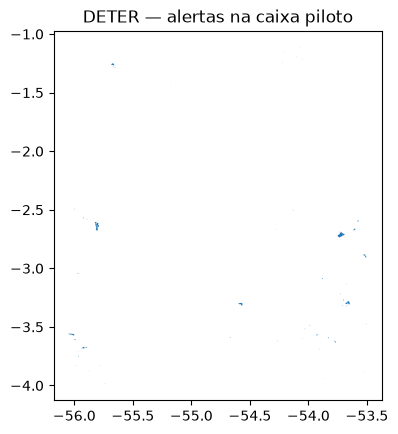

In [25]:
W, S, E, N = AREA[1], AREA[2], AREA[3], AREA[0]

if deter.crs is not None and deter.crs.to_epsg() != 4674:
    deter_geo = deter.to_crs(epsg=4674)
else:
    deter_geo = deter

deter_bbox = deter_geo.cx[W:E, S:N].copy()

print("Alertas na caixa piloto:", len(deter_bbox))

if len(deter_bbox):
    ax = deter_bbox.plot()
    ax.set_title("DETER — alertas na caixa piloto")
    plt.show()

In [26]:
deter_out = DATA_PROCESSED / "deter_piloto_bbox_v2.parquet"
deter_bbox.to_parquet(deter_out)
print("Salvo:", deter_out)

Salvo: /home/thalles24006/TCC/data/processed/deter_piloto_bbox_v2.parquet


# 14. Critério para avançar

Quando o notebook rodar até o fim, teremos validado:

- download CDS;
- separação `instant`/`accum`;
- extração automática de ZIP;
- merge sem sobrescrever coordenadas;
- interpretação temporal da precipitação;
- descoberta de camada WFS;
- descoberta de atributos;
- contagem prévia;
- captura de erros OGC;
- abertura e recorte dos alertas DETER.

Depois disso, podemos começar o desenho científico das regiões contrastantes e das séries longas.